In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
table = pq.read_table('./data/data1.parquet')
df = table.to_pandas()

In [4]:
df.rename(columns={
    'Код\nИнструмента' : 'Код инструмента',
    'Наименование\nИнструмента' : 'Наименование Инструмента',
    'Базис\nпоставки' : 'Базис поставки',
    'Объем\nДоговоров\nв единицах\nизмерения' : 'Объем договоров в ед',
    'Обьем\nДоговоров,\nруб.' : 'Объем договоров руб',
    'Изменение рыночной\nцены к цене\nпредыдуего дня' : 'Изменение рыночной цены к цене предыдуего дня руб)',
    'Col6' : 'Изменение рыночной цены к цене предыдуего дня %)', 
    'Цена (за единицу измерения), руб.' : 'Цена мин',
    'Col8' : 'Цена сред',
    'Col9' : 'Цена макс',
    'Col10' : 'Цена рын',
    'Цена\nв\nЗаявках\n(за\nединицу\nизмерения)' : 'Цена в заявках лучшее предложение)',
    'Col12' : 'Цена в заявках Лучший спрос)',
    'Количество\nДоговоров,\nшт.' : 'Количество договоров'
}, inplace=True)

In [5]:
df = df.iloc[1:,:]

In [6]:
dfc = df.copy()

In [7]:
last_col = dfc.columns[-1]
dfc = dfc[dfc[last_col]!='-']

In [8]:
col = 'Изменение рыночной цены к цене предыдуего дня руб)'

dfc[col] = dfc[col].astype(str).replace('-', '0').astype(int)

In [14]:
col = 'Изменение рыночной цены к цене предыдуего дня %)'

dfc[col] = dfc[col].astype(str).replace('-', '0').str.replace(",", ".").astype(float)

In [15]:
dfc = dfc.reset_index()

In [16]:
dfc = dfc.drop(columns=['index'])

In [17]:
dfc.head(5)

,Код инструмента,Наименование Инструмента,Базис поставки,Объем договоров в ед,Объем договоров руб,Изменение рыночной цены к цене предыдуего дня руб),Изменение рыночной цены к цене предыдуего дня %),Цена мин,Цена сред,Цена макс,Цена рын,Цена в Заявках (за единицу\nизмерения),Цена в заявках Лучший спрос),Количество договоров
0,AIE6SCI005A,"Бензин (АИ-95-К5) Евро 6, НБ Адлерская (самовы...",НБ Адлерская,5,409920,976,1.19,81984,81984,81984,81984,81984,81984,1
1,A100SCI005A,"Бензин (АИ-100-К5), НБ Адлерская (самовывоз\nа...",НБ Адлерская,5,559980,0,0.00,111996,111996,111996,111996,111996,111996,1
2,A692ALL060J,"Бензин (АИ-92-К5), ГОСТ 32513-2013/ГОСТ 32513-...",ст. Аллагуват,4020,260190060,28,0.04,64702,64724,64730,64724,64702,64730,59
3,A692ANK060F,Бензин (АИ-92-К5) (ГОСТ 32513-2013/ГОСТ 32513-...,Ангарск-группа\nстанций,2160,138544080,23,0.04,64124,64141,64147,64141,64123,64147,20
4,A692ASO005A,"Бензин (АИ-92-К5), ГОСТ 32513-2013/ГОСТ 32513-...",АСН Сургутский ЗСК,30,1950000,0,0.00,65000,65000,65000,65000,65000,65000,1


In [18]:
table = pa.Table.from_pandas(dfc)

In [19]:
pq.write_table(table, "./data/prepared_data1.parquet")

## Data


In [86]:
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import torch.nn as nn

In [113]:
table = pq.read_table("./data/prepared_data.parquet")
df = table.to_pandas()

In [114]:
df['Объем договоров в ед'] = df['Объем договоров в ед'].astype(int)
df['Объем договоров руб'] = df['Объем договоров руб'].astype(float)

df['Цена мин'] = df['Цена мин'].astype(float)
df['Цена сред'] = df['Цена сред'].replace("-", "0").astype(float)
df['Цена макс'] = df['Цена макс'].replace("-", "0").astype(float)
df['Цена рын'] = df['Цена рын'].replace("-", "0").astype(float)
df['Цена в Заявках (за единицу\nизмерения)'] = df['Цена в Заявках (за единицу\nизмерения)'].astype(float)
df['Цена в заявках Лучший спрос)'] = df['Цена в заявках Лучший спрос)'].astype(float)
df['Количество договоров'] = df['Количество договоров'].astype(int)

In [115]:
df['target'] = (df['Изменение рыночной цены к цене предыдуего дня %)'] > 0).astype(int)

df['spread'] = df['Цена макс'] - df['Цена мин']
df["mid_vs_market"] = df["Цена сред"] - df["Цена рын"]
df["volatility"] = df["spread"] / df["Цена сред"]

df["demand_gap"] = df["Цена в заявках Лучший спрос)"] - df["Цена рын"]
df["avg_contract_value"] = df["Объем договоров руб"] / df["Количество договоров"]
df["volume_per_contract"] = df["Объем договоров в ед"] / df["Количество договоров"]

df["price_change"] = df["Изменение рыночной цены к цене предыдуего дня руб)"]
df["price_change_pct"] = df["Изменение рыночной цены к цене предыдуего дня %)"]

df["price_change_lag1"] = df["price_change_pct"].shift(1)
df["price_change_lag2"] = df["price_change_pct"].shift(2)

df["min_to_mean"] = df["Цена мин"] / df["Цена сред"]
df["max_to_mean"] = df["Цена макс"] / df["Цена сред"]

df["range_position"] = ((df["Цена рын"] - df["Цена мин"]) /(df["Цена макс"] - df["Цена мин"]))

df = df.replace([float("inf"), -float("inf")], 0)

In [116]:
df = df.drop(columns=['Код инструмента', 'Наименование Инструмента', 'Базис поставки'])
df = df.drop(columns=["Изменение рыночной цены к цене предыдуего дня руб)","Изменение рыночной цены к цене предыдуего дня %)"])

In [117]:
df = df.dropna()

In [118]:
X = df.drop(columns=["target"])
y = df["target"]

In [119]:
# x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [121]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [133]:
class MarketDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [134]:
train_dataset = MarketDataset(X_train, y_train)
test_dataset = MarketDataset(X_test, y_test)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [141]:
class MLP(nn.Module):
    def __init__(self, input):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
model = MLP(X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [143]:
from sklearn.metrics import roc_auc_score

In [144]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch
        y_batch = y_batch.unsqueeze(1)

        optimizer.zero_grad()
        
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def eval_model(model, loader):
    model.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch
            
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            
            all_preds.extend(probs)
            all_targets.extend(y_batch.numpy())

    return roc_auc_score(all_targets, all_preds)

In [152]:
EPOCHS = 100
loss = []
auc = []
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    loss.append(train_loss)
    val_auc = eval_model(model, test_loader)
    auc.append(val_auc)

In [149]:
import matplotlib.pyplot as plt

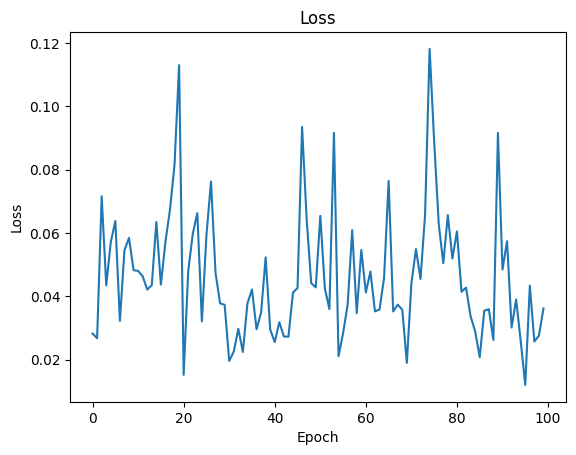

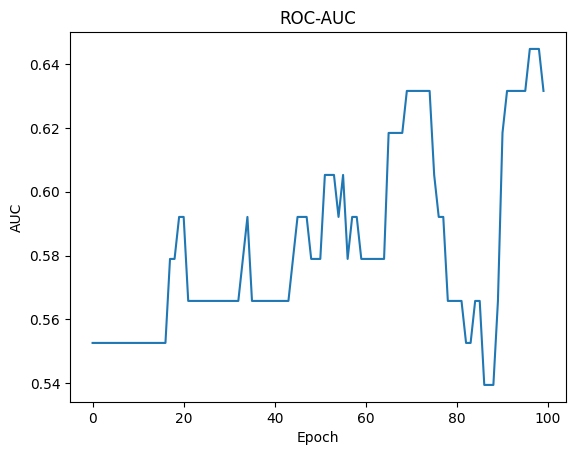

In [153]:
plt.figure()
plt.plot(loss)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(auc)
plt.title("ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.show()